In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

DATASET LOADING AND BASIC INFORMATION


In [7]:
df = pd.read_csv('/content/honeywell.csv')

In [8]:
print("--- First 5 Rows ---")
display(df.head())

--- First 5 Rows ---


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [9]:
print("\n--- Dataset Info ---")
df.info()


--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes

In [10]:
print("\n--- Summary Statistics ---")
display(df.describe())


--- Summary Statistics ---


,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


DATA VISUALISATION


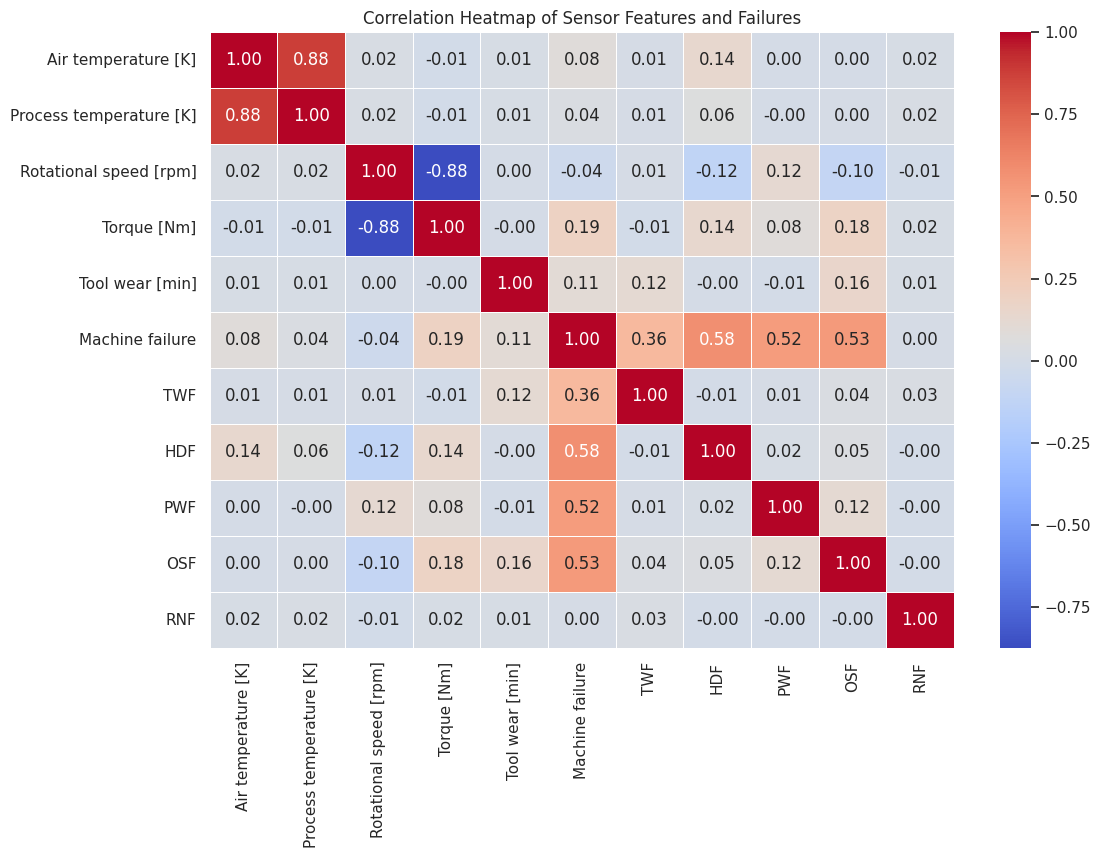

In [11]:

# Set the visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# 1. Plot Correlation Heatmap
plt.figure(figsize=(12, 8))

# We drop UDI and Product ID as they are identifiers, not physical features
numeric_df = df.drop(columns=['UDI', 'Product ID', 'Type'])
correlation = numeric_df.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Sensor Features and Failures')
plt.show()

/tmp/ipykernel_5130/2719502074.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=failure_counts.index, y=failure_counts.values, palette='viridis')


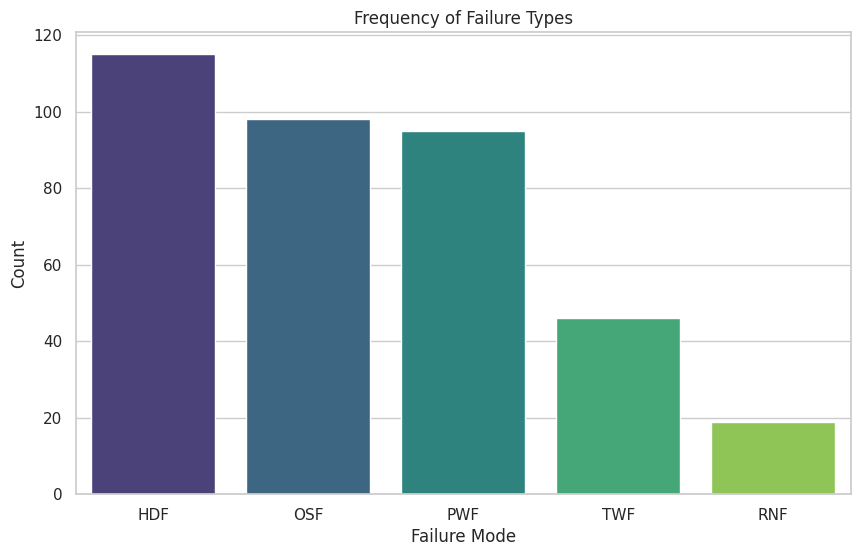

In [12]:
# 2. Show Distribution of Failure Types
# Summing the failure mode columns to see the frequency of each
failure_modes = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
failure_counts = df[failure_modes].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=failure_counts.index, y=failure_counts.values, palette='viridis')
plt.title('Frequency of Failure Types')
plt.ylabel('Count')
plt.xlabel('Failure Mode')
plt.show()

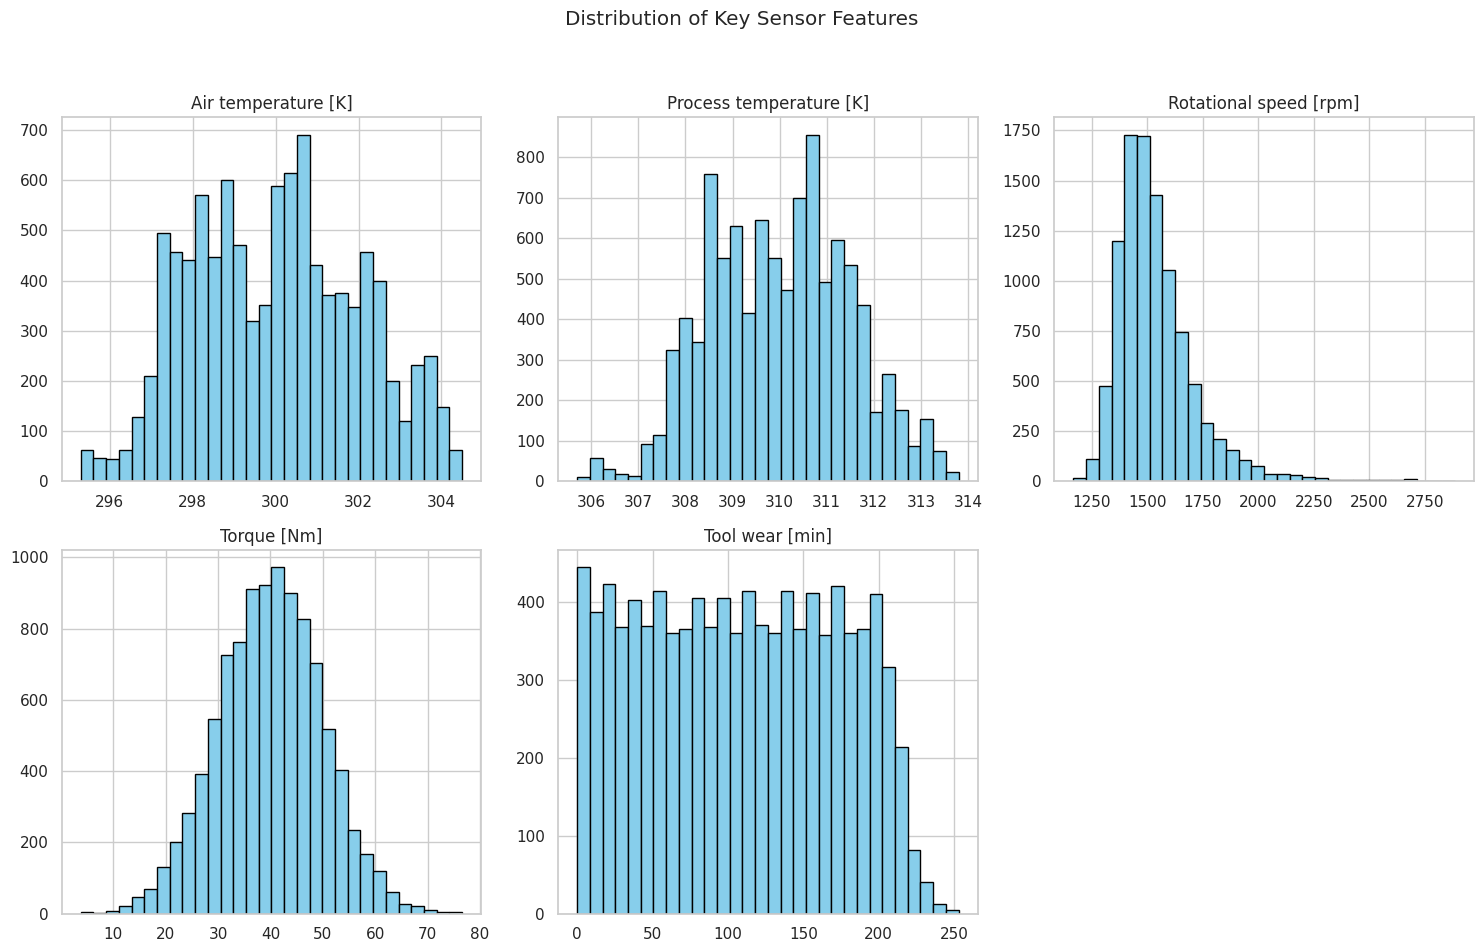

In [13]:
# 3. Plot Histogram of Key Sensor Features
sensor_features = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
df[sensor_features].hist(bins=30, figsize=(15, 10), layout=(2, 3), color='skyblue', edgecolor='black')
plt.suptitle('Distribution of Key Sensor Features')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

/tmp/ipykernel_5130/2707790274.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=melted_df, x='variable', y='value', palette='Set3')


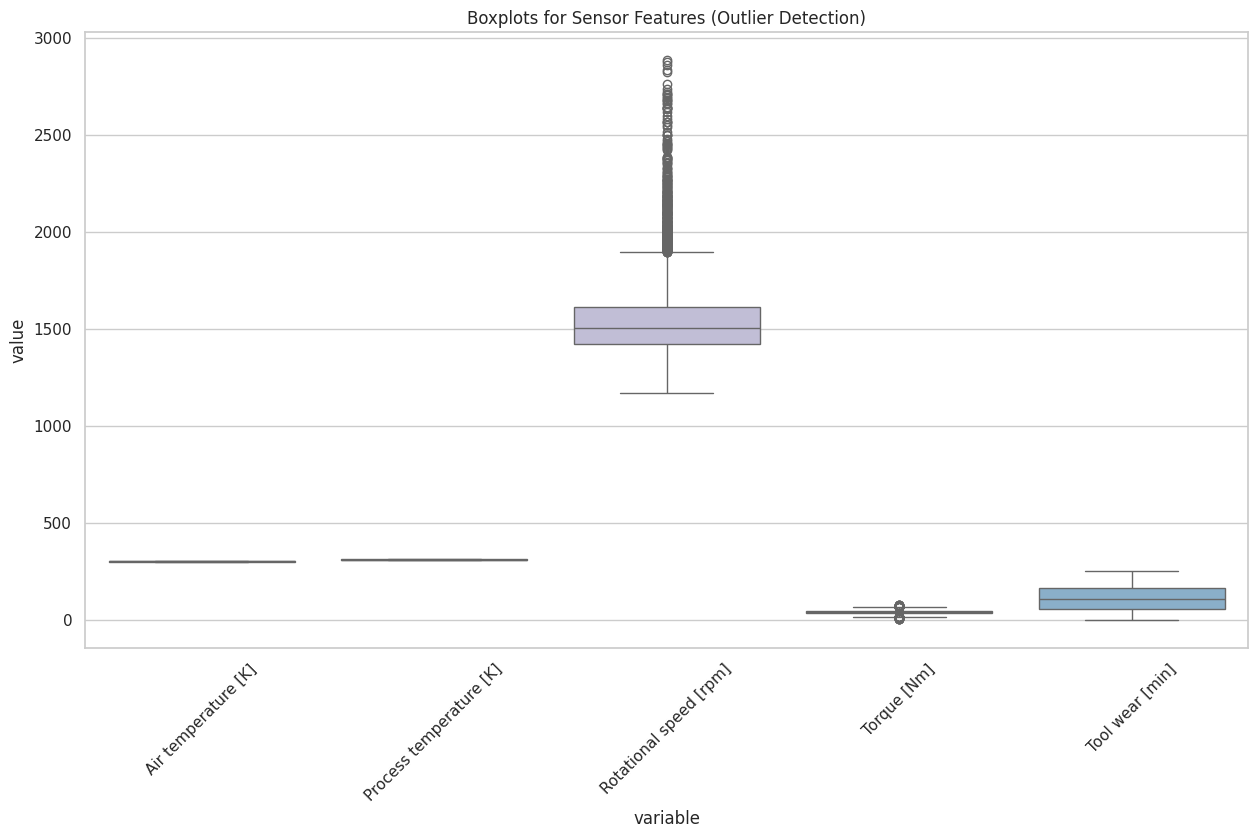

In [14]:

# 4. Show Boxplots for Outlier Detection
plt.figure(figsize=(15, 8))
# Melding the data to a long format makes it easier to plot multiple boxplots via Seaborn
melted_df = df.melt(value_vars=sensor_features)
sns.boxplot(data=melted_df, x='variable', y='value', palette='Set3')
plt.xticks(rotation=45)
plt.title('Boxplots for Sensor Features (Outlier Detection)')
plt.show()

Advanced Insights

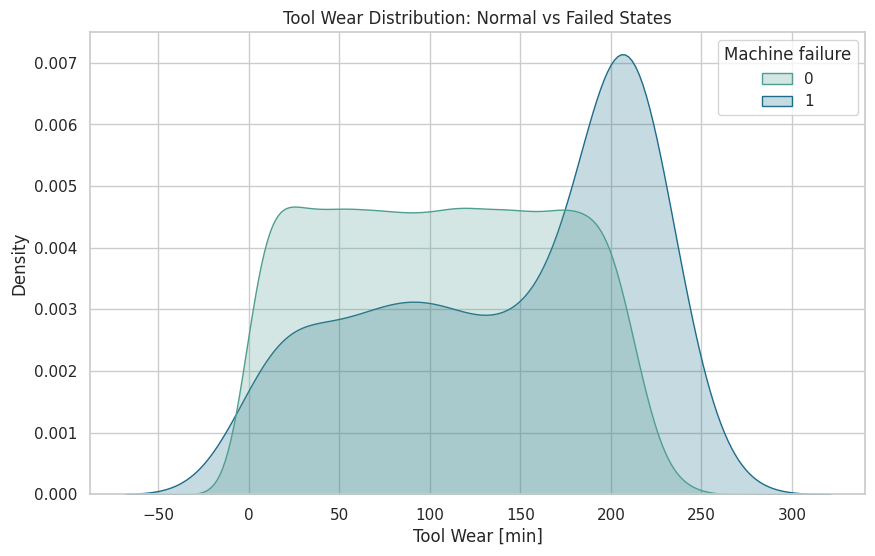

In [15]:
# Set aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

# 1. Relationship between Tool Wear and Failure
# Using a KDE plot to show the density of tool wear for failures vs non-failures
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='Tool wear [min]', hue='Machine failure', fill=True, common_norm=False, palette='crest')
plt.title('Tool Wear Distribution: Normal vs Failed States')
plt.xlabel('Tool Wear [min]')
plt.ylabel('Density')
plt.show()

Insight:

Failed machines (1) are heavily concentrated at higher tool wear (~200+ min)

Normal machines (0) are spread across lower wear values

Conclusion:

👉 Tool wear is a strong predictor of failure

Interpretation :
As tool wear increases, the probability of machine failure rises significantly, indicating degradation-driven failure behavior.

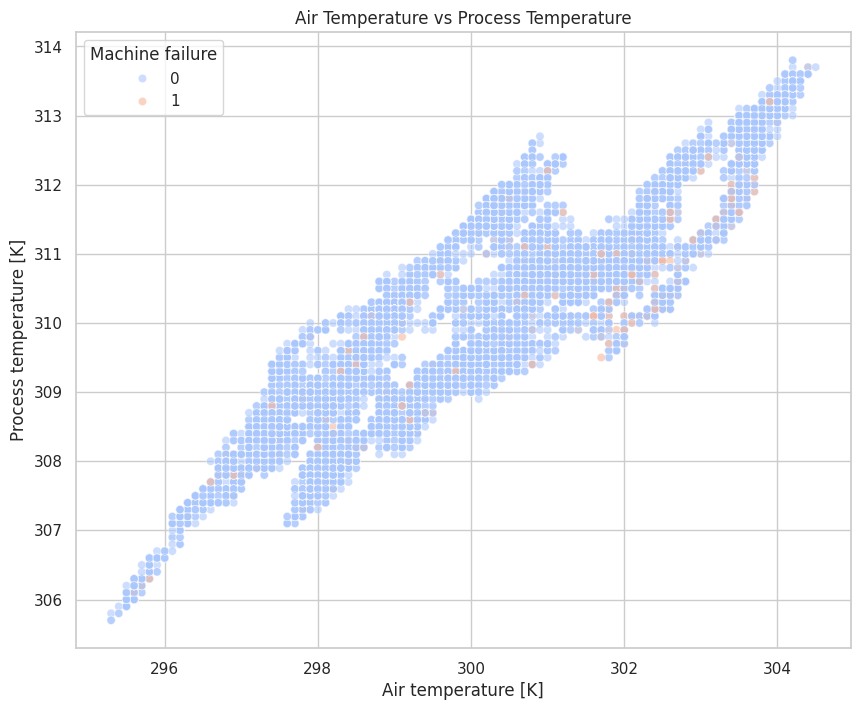

In [16]:
# 2. Temperature vs Failure
# We'll plot Air Temp vs Process Temp. Points are colored by whether a failure occurred.
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df, x='Air temperature [K]', y='Process temperature [K]',
                hue='Machine failure', alpha=0.6, palette='coolwarm')
plt.title('Air Temperature vs Process Temperature')
plt.show()

Insight:

Strong linear relationship between air temp and process temp
Failure points are not clearly separable from normal points

Conclusion:
These features are correlated but weak predictors of failure
Interpretation:
Temperature variables exhibit high inter-correlation but do not independently distinguish failure conditions effectively.

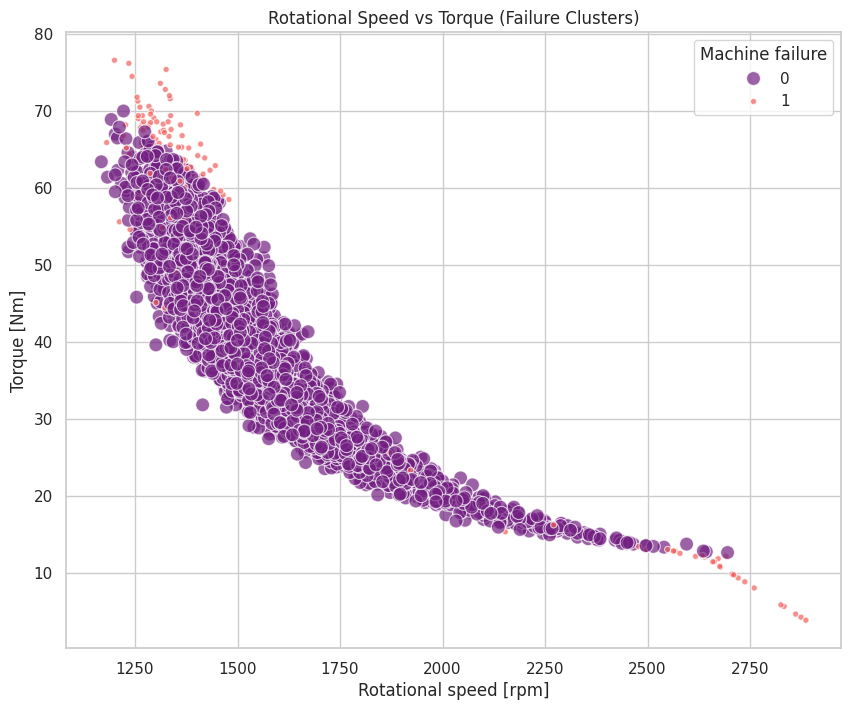

In [17]:
# 3. Rotational Speed vs Torque vs Failure
# These two features are inversely related (high speed usually means lower torque).
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df, x='Rotational speed [rpm]', y='Torque [Nm]',
                hue='Machine failure', size='Machine failure', sizes=(20, 100),
                alpha=0.7, palette='magma')
plt.title('Rotational Speed vs Torque (Failure Clusters)')
plt.show()

Insight: Clear inverse relationship:

High RPM → Low Torque

Low RPM → High Torque

Failures appear more in:
High torque regions,
Low speed zones

Conclusion:
Mechanical stress (torque-heavy conditions) contributes to failure
Interpretation:
Failure instances are more frequent under high torque and low rotational speed conditions, suggesting mechanical overload as a critical factor.

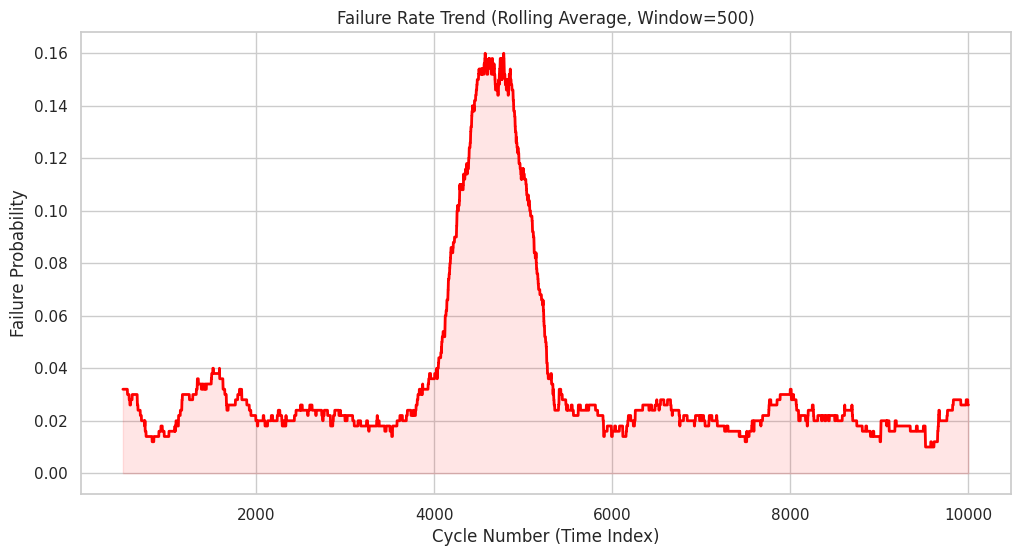

In [18]:
# 4. Time-based Trends (Using UID as a proxy for time)
# We look at the rolling failure rate to see if failures become more frequent over time.
window_size = 500
df['Failure_Rolling_Rate'] = df['Machine failure'].rolling(window=window_size).mean()

plt.figure(figsize=(12, 6))
plt.plot(df['UDI'], df['Failure_Rolling_Rate'], color='red', linewidth=2)
plt.title(f'Failure Rate Trend (Rolling Average, Window={window_size})')
plt.xlabel('Cycle Number (Time Index)')
plt.ylabel('Failure Probability')
plt.fill_between(df['UDI'], df['Failure_Rolling_Rate'], color='red', alpha=0.1)
plt.show()

Insight:

Sudden spike in failure probability around mid cycles (~4000–5000)

Otherwise mostly stable low failure rate

Conclusion:
System degradation phase
Batch-related issue
Maintenance gap

Interpretation:
A temporal spike in failure rate suggests non-random failure behavior, potentially linked to operational cycles or maintenance inefficiencies.

**EDA SUMMARY** :

1.Tool wear and torque are the most influential features affecting machine failure.

2.Temperature variables are highly correlated and provide limited independent predictive value.

3.Mechanical stress conditions (high torque, low speed) significantly increase failure likelihood.

4.Failure occurrence shows temporal spikes, indicating possible operational or maintenance-related patterns.

5.The dataset contains class imbalance across failure types and notable outliers in key sensor features.